<!--
Copyright (c) 2025-2026, NVIDIA CORPORATION. All rights reserved.

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

 http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Aim
The purpose of this notebook is to show how to use JIT to tune a Stable Diffusion XL model.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd
%pip install diffusers<=0.34.0 transformers>=4.54,<5 matplotlib

In [ ]:
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
import torch

from diffusers import StableDiffusionXLPipeline
from notebooks.jit.jit_commons import visualize_latency, benchmark

from PIL import Image

prompt = "A fluffy, orange tabby cat with bright green eyes is captured mid-air, pouncing playfully on a vibrant red ball of yarn"

/home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[08/08/2025-10:24:39] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


# Stable Diffusion XL

Diffusion models have an internal diffusion loop. Hence it is important to set `min_samples` to a proper value. 
Otherwise, JIT won't see samples with different batch sizes and TRT backend will create static shapes.

In [ ]:
config.dry_run = False
config.min_samples = 4
config.max_depth_level = 2
config.detect_graph_breaks = True
# config.skip_modules = ["UNet2DConditionModel", "Decoder"]

In [ ]:
@patch_for_jit_tuning
def create_model():
    pipe = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16")
    pipe.to("cuda")
    return pipe

In [5]:
pipe = create_model()

Loading pipeline components...:  29%|██▊       | 2/7 [00:00<00:00,  7.64it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 14.82it/s]


100%|██████████| 1/1 [00:00<00:00, 14.93it/s]
10:24:46.823 - INFO - ------------------------------------------------------------
10:24:46.823 - INFO - 🚀 Tuning graph `0` for module `CLIPTextModel 📊123.1M`:
10:24:46.824 - INFO -   number of parameters: 123.1M
10:24:46.824 - INFO -   number of layers: 1
10:24:46.824 - INFO -   precisions: torch.float16
10:24:46.825 - INFO -   graph_spec:
10:24:46.825 - INFO -     input_spec: ((input__0[dim0, 77] min_shape=[1, 77] max_shape=[2, 77] dtype=torch.int64,), {output_hidden_states: True})
10:24:46.825 - INFO -     output_spec: {hidden_states: (output__0[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__1[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__2[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__3[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__4[dim0, 77, 768] min_shape=[1, 77

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


10:24:49.675 - WARNING - [W] ModelImporter.cpp:459: Make sure input input__0 has Int64 binding.
10:24:49.723 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 77), opt=(2, 77), max=(2, 77)]}
    ]
10:24:49.725 - WARNING - [W] profileSharing0806 is on by default in TensorRT 10.0. This flag is deprecated and has no effect.
10:24:49.725 - Level 22 - [I] Building engine with configuration:
    Flags                  | [STRONGLY_TYPED]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
10:24:52.929 - Level 28 - [I] Finished engine building in 3.203 seconds
10:24:53.028 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/25493567cb626e7ca0204358f

[08/08/2025-10:24:53] [TRT] [I] Loaded engine size: 236 MiB
[08/08/2025-10:24:53] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +3, now: CPU 0, GPU 237 (MiB)


10:24:54.133 - INFO - ------------------------------------------------------------
10:24:54.134 - INFO - 🚀 Tuning graph `0` for module `CLIPTextTransformer 📊123.1M`:
10:24:54.134 - INFO -   number of parameters: 123.1M
10:24:54.135 - INFO -   number of layers: 3
10:24:54.135 - INFO -   precisions: torch.float16
10:24:54.135 - INFO -   graph_spec:
10:24:54.135 - INFO -     input_spec: ((), {attention_mask: None, input_ids: input__0[dim0, 77] min_shape=[1, 77] max_shape=[2, 77] dtype=torch.int64, output_attentions: None, output_hidden_states: True, position_ids: None})
10:24:54.135 - INFO -     output_spec: {hidden_states: (output__0[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__1[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__2[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, output__3[dim0, 77, 768] min_shape=[1, 77, 768] max_shape=[2, 77, 768] dtype=torch.float16, ou

...

10:27:51.998 - INFO -     ✅ backend validated
10:27:51.998 - INFO - 🎯 Strategy JitStrategy execution finished in 1m 45s.
10:27:51.998 - INFO - ✅ Selected backend: TensorRTBackend(quantization_config=None)
100%|██████████| 1/1 [02:01<00:00, 121.69s/it]
10:27:52.100 - INFO - ------------------------------------------------------------
10:27:52.100 - INFO - 🚀 Tuning graph `0` for module `Conv2d 📊20`:
10:27:52.101 - INFO -   number of parameters: 20
10:27:52.101 - INFO -   number of layers: 0
10:27:52.101 - INFO -   precisions: torch.float16
10:27:52.101 - INFO -   graph_spec:
10:27:52.101 - INFO -     input_spec: ((input__0[dim0, 4, 128, 128] min_shape=[1, 4, 128, 128] max_shape=[2, 4, 128, 128] dtype=torch.float16,), {})
10:27:52.101 - INFO -     output_spec: output__0[dim0, 4, 128, 128] min_shape=[1, 4, 128, 128] max_shape=[2, 4, 128, 128] dtype=torch.float16
10:27:52.101 - INFO -   num samples: 1
10:27:52.102 - INFO -   device: cuda
10:27:52.102 - INFO -   cache_dir: /home/pbazan/.cach

[08/08/2025-10:27:54] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/08/2025-10:27:54] [TRT] [I] Loaded engine size: 0 MiB
[08/08/2025-10:27:54] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +1, now: CPU 0, GPU 5659 (MiB)


10:27:56.206 - INFO - ------------------------------------------------------------
10:27:56.207 - INFO - 🚀 Tuning graph `0` for module `Decoder 📊49.5M`:
10:27:56.207 - INFO -   number of parameters: 49.5M
10:27:56.207 - INFO -   number of layers: 6
10:27:56.208 - INFO -   precisions: torch.float32, torch.float16
10:27:56.208 - INFO -   graph_spec:
10:27:56.208 - INFO -     input_spec: ((input__0[dim0, 4, 128, 128] min_shape=[1, 4, 128, 128] max_shape=[2, 4, 128, 128] dtype=torch.float16,), {})
10:27:56.208 - INFO -     output_spec: output__0[dim0, 3, 1024, 1024] min_shape=[1, 3, 1024, 1024] max_shape=[2, 3, 1024, 1024] dtype=torch.float32
10:27:56.208 - INFO -   num samples: 1
10:27:56.208 - INFO -   device: cuda
10:27:56.208 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/b36bb5cdfcac54c1bd35b49412fdc0a9095ec78ea69439c74bb3b530d23fcc51/0
10:27:56.208 - INFO -   strategy:
10:27:56.209 - INFO -     name: JIT Strategy
10:27:56.209 - INFO -     description: tailored for JIT tuning
10

[08/08/2025-10:29:58] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/08/2025-10:29:58] [TRT] [I] Loaded engine size: 290 MiB
[08/08/2025-10:29:58] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +6312, now: CPU 0, GPU 12263 (MiB)


10:29:58.734 - INFO -     ✅ backend validated
10:29:58.734 - INFO - 🎯 Strategy JitStrategy execution finished in 2m 3s.
10:29:58.735 - INFO - ✅ Selected backend: TensorRTBackend(quantization_config=None)
100%|██████████| 1/1 [00:00<00:00,  4.65it/s]
10:30:00.094 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.12/site-packages/diffusers/image_processor.py:147: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")

100%|██████████| 1/1 [00:00<00:00,  4.15it/s]


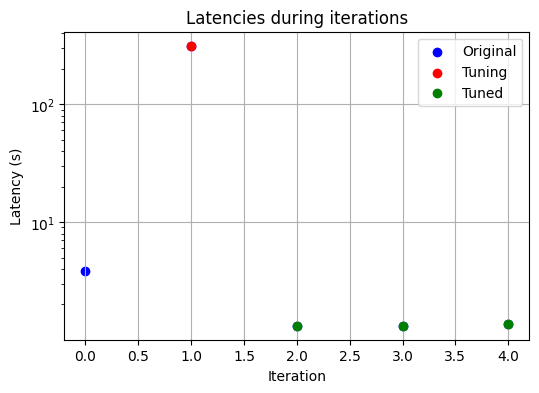

In [ ]:
def batch():
    with torch.no_grad():
        pipe([prompt] * 1, num_inference_steps=1)
        pipe([prompt] * 2, num_inference_steps=1)

visualize_latency(lambda: batch(), iterations=5)

In [7]:
PatchedModule.history

['New top module: CLIPTextModel 📊123.1M level=0🪜 state=init⏳ call_count=1',
 'New child module: CLIPTextTransformer 📊123.1M level=1🪜 state=init⏳ call_count=1',
 'New top module: CLIPTextModelWithProjection 📊694.7M level=0🪜 state=init⏳ call_count=1',
 'New child module: CLIPTextTransformer 📊693.0M level=1🪜 state=init⏳ call_count=1',
 'New child module: Linear 📊1.6M level=1🪜 state=init⏳ call_count=1',
 'New top module: UNet2DConditionModel 📊2.6B level=0🪜 state=init⏳ call_count=1',
 'New child module: TimestepEmbedding 📊2.1M level=1🪜 state=init⏳ call_count=1',
 'New child module: TimestepEmbedding 📊5.2M level=1🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊11.8K level=1🪜 state=init⏳ call_count=1',
 'New child module: DownBlock2D 📊5.4M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnDownBlock2D 📊60.1M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnDownBlock2D 📊757.4M level=1🪜 state=init⏳ call_count=1',
 'New child module: UNetMidBlock2DCrossAttn

In [8]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ CLIPTextModel 📊123.1M level=0🪜 state=eager⚠️ (tuning error) call_count=4
  ├─ CLIPTextTransformer 📊123.1M level=1🪜 state=eager⚠️ (tuning error) call_count=4
├─ CLIPTextModelWithProjection 📊694.7M level=0🪜 state=eager⚠️ (tuning error) call_count=4
  ├─ CLIPTextTransformer 📊693.0M level=1🪜 state=eager⚠️ (tuning error) call_count=4
  ├─ Linear 📊1.6M level=1🪜 state=tuned🎯 (TensorRTBackend) call_count=4
├─ UNet2DConditionModel 📊2.6B level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
  ├─ TimestepEmbedding 📊2.1M level=1🪜 state=detached☑️ call_count=4
  ├─ TimestepEmbedding 📊5.2M level=1🪜 state=detached☑️ call_count=4
  ├─ Conv2d 📊11.8K level=1🪜 state=detached☑️ call_count=4
  ├─ DownBlock2D 📊5.4M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnDownBlock2D 📊60.1M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnDownBlock2D 📊757.4M level=1🪜 state=detached☑️ call_count=4
  ├─ UNetMidBlock2DCrossAttn 📊413.1M level=1🪜 state=detached☑️ call_count=4
  ├─ Cross

In [9]:
resp = pipe([prompt] * 1)

  4%|▍         | 2/50 [00:00<00:05,  9.09it/s]

100%|██████████| 50/50 [00:06<00:00,  8.19it/s]


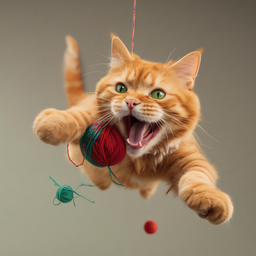

In [10]:
# resize image so that it does no take much space in notebook
img = resp["images"][0]
img_resized = img.resize((256, 256), Image.LANCZOS)
img_resized

# Benchmark

### JIT tuned pipeline

In [ ]:
benchmark(lambda: pipe([prompt]), iterations=3)

  4%|▍         | 2/50 [00:00<00:05,  9.49it/s]

100%|██████████| 50/50 [00:06<00:00,  8.11it/s]


'6.49s ± 0.0306 (3 iterations)'

### Original model

In [12]:
pipe = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda");

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.59it/s]


In [ ]:
benchmark(lambda: pipe([prompt]), iterations=3)


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:08<00:00,  5.71it/s]


'9.07s ± 0.0868 (3 iterations)'